In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 10_Property_stolen_and_recovered.csv to 10_Property_stolen_and_recovered.csv
Saving 20_Victims_of_rape.csv to 20_Victims_of_rape.csv
Saving 30_Auto_theft.csv to 30_Auto_theft.csv
Saving 35_Human_rights_violation_by_police.csv to 35_Human_rights_violation_by_police.csv
Saving crime-in-india.ipynb to crime-in-india.ipynb


In [ ]:
property_df = pd.read_csv("10_Property_stolen_and_recovered.csv")
rape_df = pd.read_csv("20_Victims_of_rape.csv")
auto_df = pd.read_csv("30_Auto_theft.csv")
hr_df = pd.read_csv("35_Human_rights_violation_by_police.csv")
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
# missing vals
datasets = {
    "Property Stolen & Recovered": property_df,
    "Victims of Rape": rape_df,
    "Auto Theft": auto_df,
    "Human Rights Violations": hr_df
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Missing Values:", df.isnull().sum().sum())
    print("Duplicate Rows:", df.duplicated().sum())


Property Stolen & Recovered
Rows: 2449
Columns: 8
Missing Values: 0
Duplicate Rows: 0

Victims of Rape
Rows: 1050
Columns: 11
Missing Values: 0
Duplicate Rows: 0

Auto Theft
Rows: 1865
Columns: 7
Missing Values: 374
Duplicate Rows: 0

Human Rights Violations
Rows: 2267
Columns: 7
Missing Values: 160
Duplicate Rows: 0


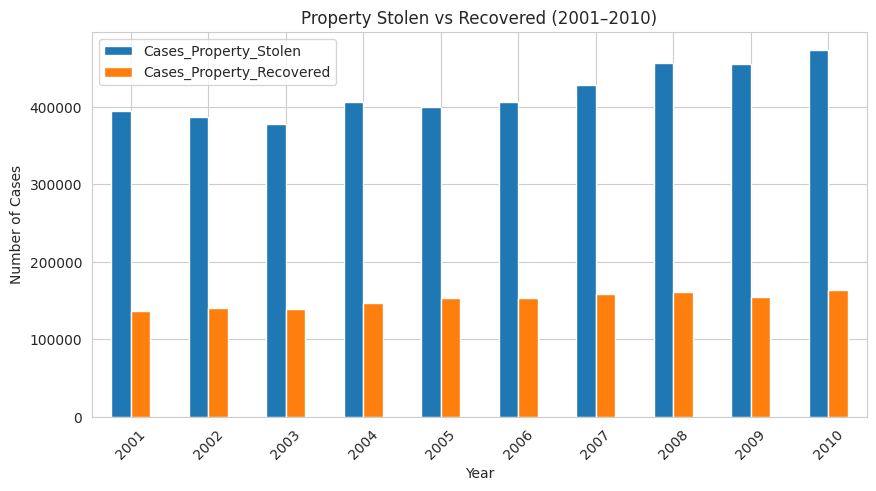

In [ ]:
# prop stolen and rec
property_total = property_df[
    property_df["Sub_Group_Name"] == "7. Total Property Stolen & Recovered"
]

property_year = property_total.groupby("Year")[
    ["Cases_Property_Stolen", "Cases_Property_Recovered"]
].sum()

property_year.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Property Stolen vs Recovered (2001–2010)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)

plt.show()

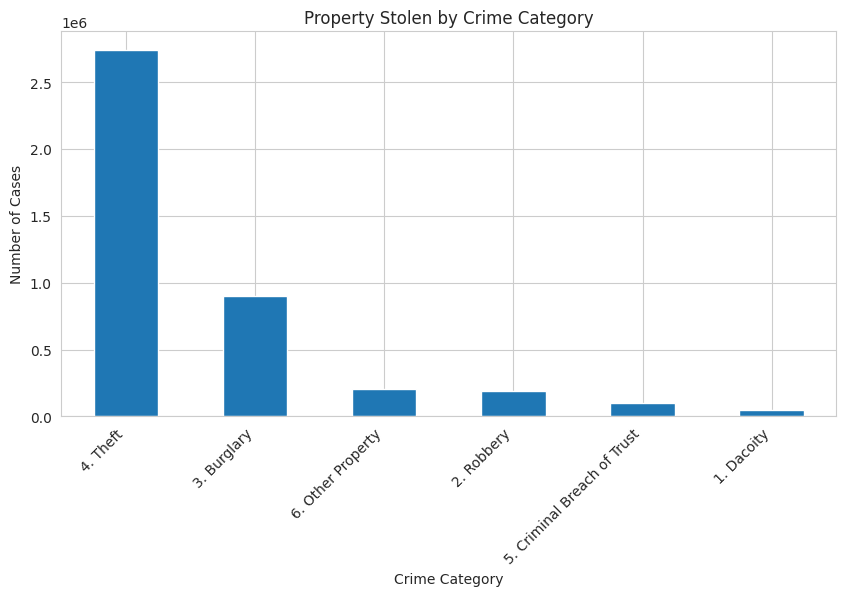

In [ ]:
# pro crime cat
property_categories = property_df[
    property_df["Sub_Group_Name"] != "7. Total Property Stolen & Recovered"
]

category = property_categories.groupby(
    "Sub_Group_Name"
)["Cases_Property_Stolen"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

category.plot(kind="bar")

plt.title("Property Stolen by Crime Category")
plt.xlabel("Crime Category")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")

plt.show()

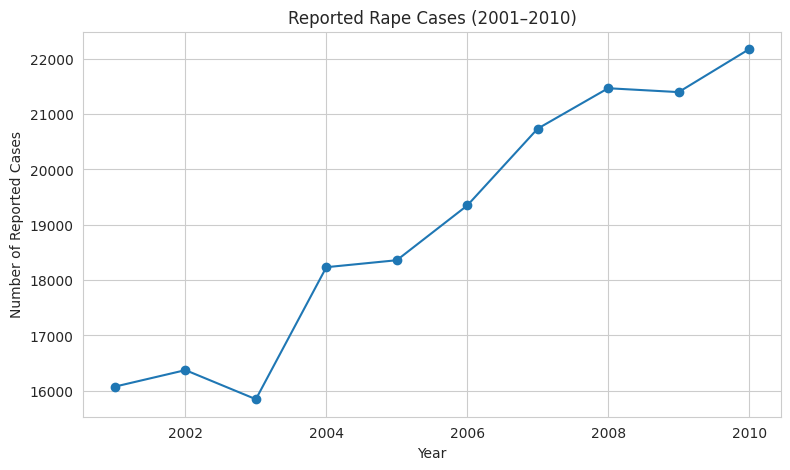

In [ ]:
# rape cases
rape_total = rape_df[
    rape_df["Subgroup"] == "Total Rape Victims"
]

rape_year = rape_total.groupby("Year")[
    "Rape_Cases_Reported"
].sum()

plt.figure(figsize=(9,5))

plt.plot(
    rape_year.index,
    rape_year.values,
    marker="o"
)

plt.title("Reported Rape Cases (2001–2010)")
plt.xlabel("Year")
plt.ylabel("Number of Reported Cases")

plt.show()

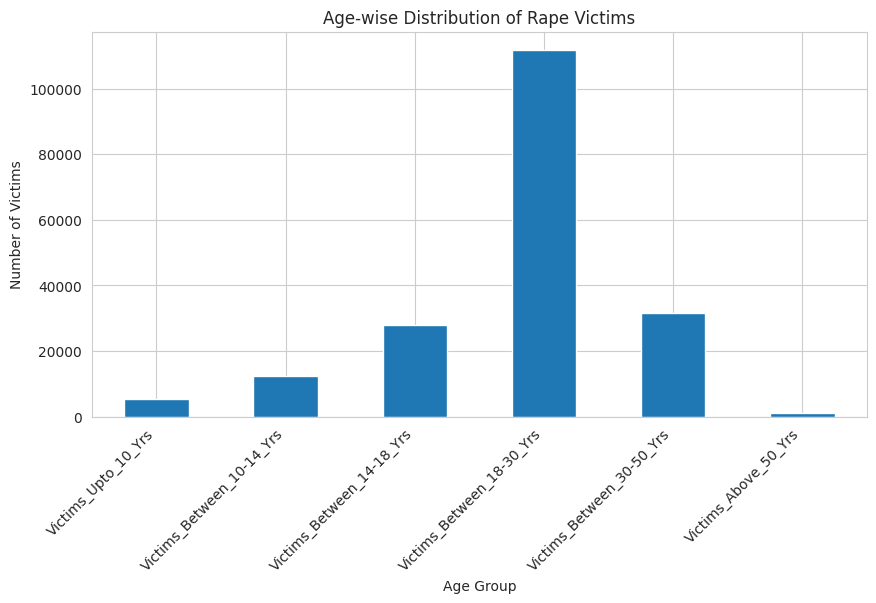

In [ ]:
# rape age
age_columns = [
    "Victims_Upto_10_Yrs",
    "Victims_Between_10-14_Yrs",
    "Victims_Between_14-18_Yrs",
    "Victims_Between_18-30_Yrs",
    "Victims_Between_30-50_Yrs",
    "Victims_Above_50_Yrs"
]

age_data = rape_total[age_columns].sum()

plt.figure(figsize=(10,5))

age_data.plot(kind="bar")

plt.title("Age-wise Distribution of Rape Victims")
plt.xlabel("Age Group")
plt.ylabel("Number of Victims")
plt.xticks(rotation=45, ha="right")

plt.show()

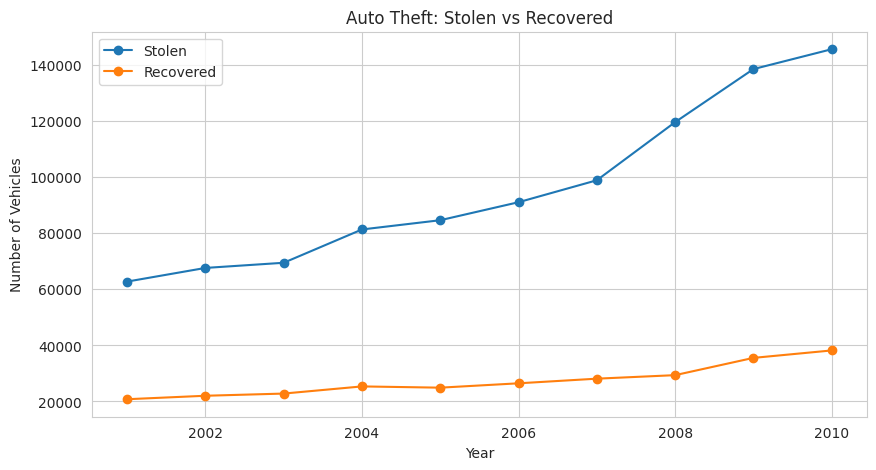

In [ ]:
# auto theft stolen and rec
auto_total = auto_df[
    auto_df["Sub_Group_Name"] == "6. Total (Sum of 1-5 Above)"
]

auto_year = auto_total.groupby("Year")[
    ["Auto_Theft_Stolen", "Auto_Theft_Recovered"]
].sum()

plt.figure(figsize=(10,5))

plt.plot(
    auto_year.index,
    auto_year["Auto_Theft_Stolen"],
    marker="o",
    label="Stolen"
)

plt.plot(
    auto_year.index,
    auto_year["Auto_Theft_Recovered"],
    marker="o",
    label="Recovered"
)

plt.title("Auto Theft: Stolen vs Recovered")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")

plt.legend()
plt.show()

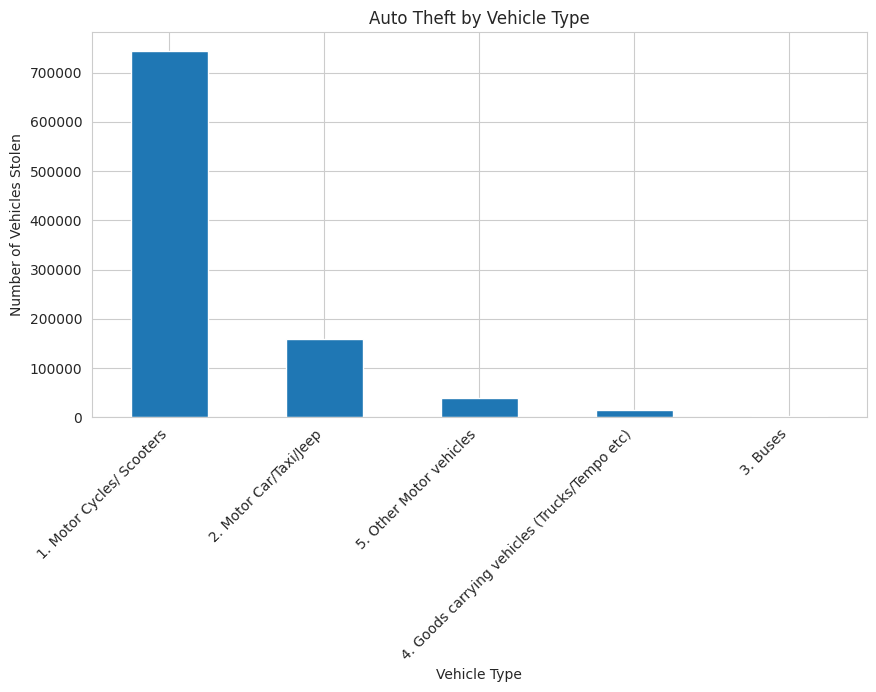

In [ ]:
# type
auto_categories = auto_df[
    auto_df["Sub_Group_Name"] != "6. Total (Sum of 1-5 Above)"
]

vehicle_type = auto_categories.groupby(
    "Sub_Group_Name"
)["Auto_Theft_Stolen"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

vehicle_type.plot(kind="bar")

plt.title("Auto Theft by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles Stolen")
plt.xticks(rotation=45, ha="right")

plt.show()

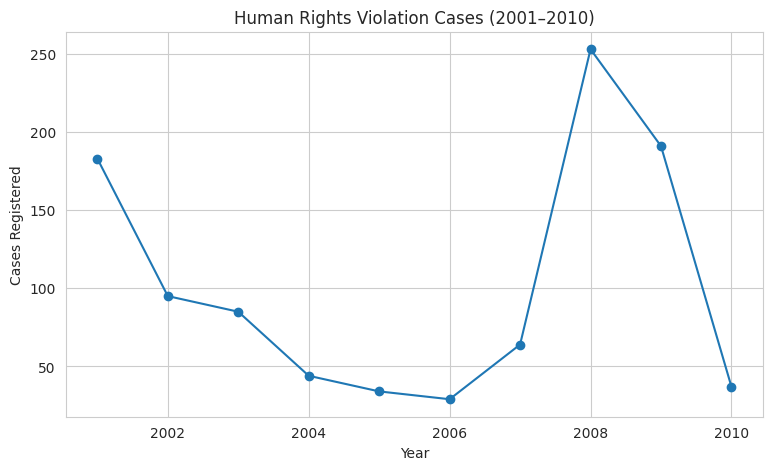

In [ ]:
# human ryts
hr_total = hr_df[
    hr_df["Sub_Group_Name"] == "12. Total (Sum of 1-11 Above)"
]

hr_year = hr_total.groupby("Year")[
    "Cases_Registered_under_Human_Rights_Violations"
].sum()

plt.figure(figsize=(9,5))

plt.plot(
    hr_year.index,
    hr_year.values,
    marker="o"
)

plt.title("Human Rights Violation Cases (2001–2010)")
plt.xlabel("Year")
plt.ylabel("Cases Registered")

plt.show()

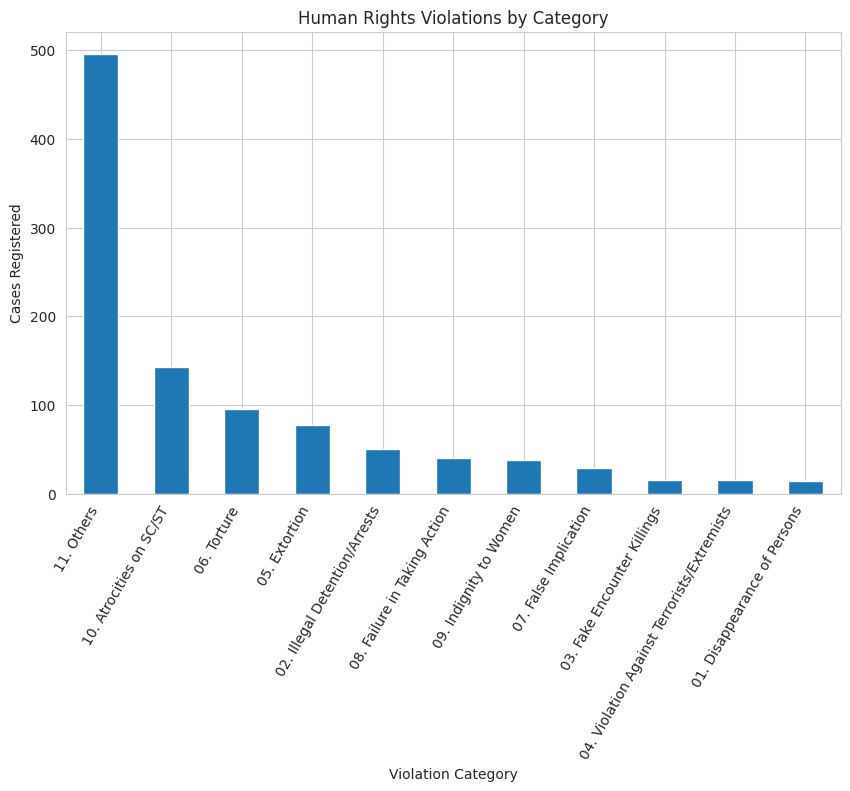

In [ ]:
# HR cat
hr_categories = hr_df[
    hr_df["Sub_Group_Name"] != "12. Total (Sum of 1-11 Above)"
]

hr_category = hr_categories.groupby(
    "Sub_Group_Name"
)["Cases_Registered_under_Human_Rights_Violations"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

hr_category.plot(kind="bar")

plt.title("Human Rights Violations by Category")
plt.xlabel("Violation Category")
plt.ylabel("Cases Registered")
plt.xticks(rotation=60, ha="right")

plt.show()

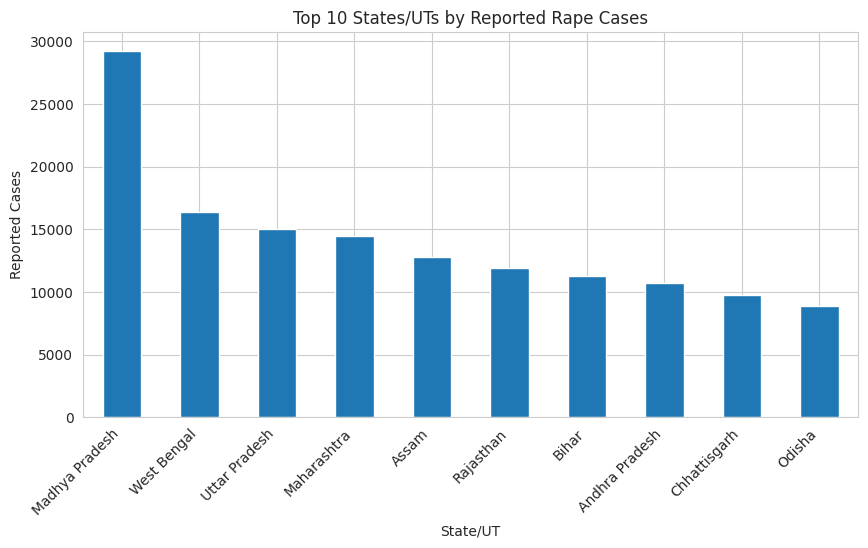

In [ ]:
# all datasets state wise
state_analysis = rape_total.groupby(
    "Area_Name"
)["Rape_Cases_Reported"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

state_analysis.plot(kind="bar")

plt.title("Top 10 States/UTs by Reported Rape Cases")
plt.xlabel("State/UT")
plt.ylabel("Reported Cases")
plt.xticks(rotation=45, ha="right")

plt.show()